In [2]:
import numpy as np
import json
import os
import matplotlib.pyplot as plt
from collections import defaultdict

DATA_PATH = "D:/soccernet-data"

competitions = os.listdir(DATA_PATH)
print("Competitions found:")
for c in competitions:
    print(f"  - {c}")
print(f"\nTotal competitions: {len(competitions)}")

Competitions found:
  - england_epl
  - europe_uefa-champions-league
  - france_ligue-1
  - germany_bundesliga
  - italy_serie-a
  - spain_laliga

Total competitions: 6


In [3]:
all_games = []

for competition in competitions:
    competition_path = os.path.join(DATA_PATH, competition)
    for season in os.listdir(competition_path):
        season_path = os.path.join(competition_path, season)
        for game in os.listdir(season_path):
            game_path = os.path.join(season_path, game)
            all_games.append(game_path)

print(f"Total games found: {len(all_games)}")
print(f"\nFirst 5 game paths:")
for g in all_games[:5]:
    print(f"  {g}")

Total games found: 500

First 5 game paths:
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Chelsea 1 - 1 Burnley
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Crystal Palace 1 - 2 Arsenal
  D:/soccernet-data\england_epl\2014-2015\2015-02-21 - 18-00 Swansea 2 - 1 Manchester United
  D:/soccernet-data\england_epl\2014-2015\2015-02-22 - 19-15 Southampton 0 - 2 Liverpool
  D:/soccernet-data\england_epl\2014-2015\2015-04-11 - 19-30 Burnley 0 - 1 Arsenal


In [5]:
action_counts = defaultdict(int)
total_annotations = 0
games_with_labels = 0
games_without_labels = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    
    if not os.path.exists(label_path):
        games_without_labels += 1
        continue
    
    games_with_labels += 1
    with open(label_path, "r") as f:
        data = json.load(f)
    
    for annotation in data["annotations"]:
        action_counts[annotation["label"]] += 1
        total_annotations += 1

print(f"Games with labels: {games_with_labels}")
print(f"Games without labels: {games_without_labels}")
print(f"Total annotations: {total_annotations}")
print(f"\nAction counts (sorted by frequency):")
for action, count in sorted(action_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {action}: {count}")

Games with labels: 500
Games without labels: 0
Total annotations: 110458

Action counts (sorted by frequency):
  Ball out of play: 31810
  Throw-in: 18918
  Foul: 11674
  Indirect free-kick: 10521
  Clearance: 7896
  Shots on target: 5820
  Shots off target: 5256
  Corner: 4836
  Substitution: 2839
  Kick-off: 2566
  Direct free-kick: 2200
  Offside: 2098
  Yellow card: 2047
  Goal: 1703
  Penalty: 173
  Red card: 55
  Yellow->red card: 46


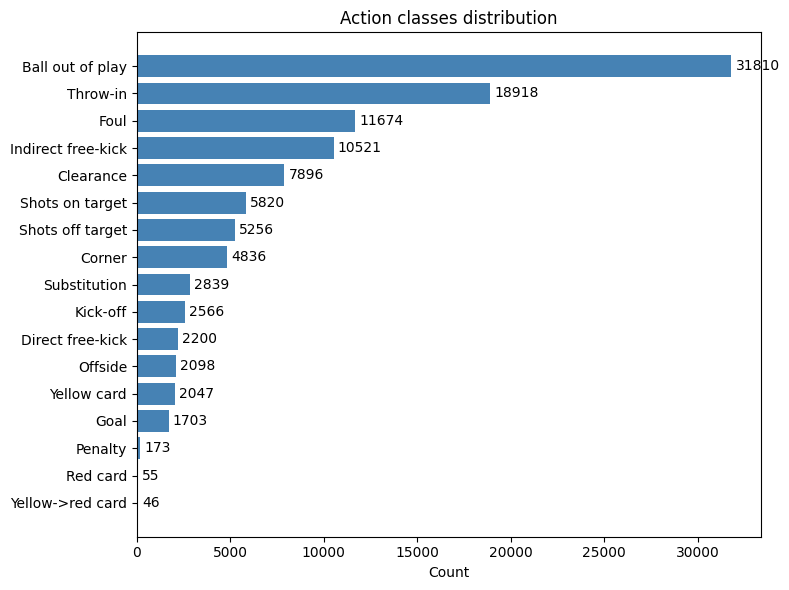

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

actions = list(action_counts.keys())
counts = list(action_counts.values())
sorted_pairs = sorted(zip(counts, actions), reverse=True)
counts_sorted, actions_sorted = zip(*sorted_pairs)

bars = ax.barh(actions_sorted, counts_sorted, color="steelblue")

ax.set_xlabel("Count")
ax.set_title("Action classes distribution")
ax.invert_yaxis()

ax.bar_label(bars, padding=3)

plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
sample_game = all_games[0]
half1_path = os.path.join(sample_game, "1_ResNET_TF2_PCA512.npy")
half2_path = os.path.join(sample_game, "2_ResNET_TF2_PCA512.npy")

half1 = np.load(half1_path)
half2 = np.load(half2_path)

print(f"Game: {os.path.basename(sample_game)}")
print(f"\nHalf 1 shape: {half1.shape}")
print(f"Half 2 shape: {half2.shape}")
print(f"\nWhat this means:")
print(f"  Frames in half 1: {half1.shape[0]} ({half1.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Frames in half 2: {half2.shape[0]} ({half2.shape[0]/2/60:.1f} minutes at 2fps)")
print(f"  Feature dimensions per frame: {half1.shape[1]}")
print(f"\nFeature statistics for half 1:")
print(f"  Min value: {half1.min():.4f}")
print(f"  Max value: {half1.max():.4f}")
print(f"  Mean value: {half1.mean():.4f}")
print(f"  Std value: {half1.std():.4f}")

In [ ]:
label_path = os.path.join(sample_game, "Labels-v2.json")
with open(label_path, "r") as f:
    data = json.load(f)

print(f"Game: {os.path.basename(sample_game)}")
print(f"Total annotations in this game: {len(data['annotations'])}")
print(f"\nAll annotations:")
for ann in data["annotations"]:
    
    game_time = ann["gameTime"]
    half = int(game_time.split(" - ")[0])
    time_str = game_time.split(" - ")[1]
    minutes, seconds = map(int, time_str.split(":"))
    total_seconds = minutes * 60 + seconds
    frame_index = int(total_seconds * 2)
    
    print(f"  [{ann['label']}] Half {half} | {time_str} | "
          f"position={ann['position']}ms | frame_index={frame_index}")

In [12]:
import sys
sys.path.append("../src")
from dataset import SELECTED_CLASSES

annotations_per_game = []
selected_counts_per_class = defaultdict(int)
games_with_zero = 0

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    game_annotations = [a for a in data["annotations"] 
                        if a["label"] in SELECTED_CLASSES]
    annotations_per_game.append(len(game_annotations))
    
    for ann in game_annotations:
        selected_counts_per_class[ann["label"]] += 1
    
    if len(game_annotations) == 0:
        games_with_zero += 1

print("Selected class totals across all 500 games:")
for cls in SELECTED_CLASSES:
    print(f"  {cls}: {selected_counts_per_class[cls]}")

print(f"\nTotal selected annotations: {sum(selected_counts_per_class.values())}")
print(f"Games with zero selected annotations: {games_with_zero}")
print(f"\nAnnotations per game statistics:")
print(f"  Min: {min(annotations_per_game)}")
print(f"  Max: {max(annotations_per_game)}")
print(f"  Mean: {np.mean(annotations_per_game):.1f}")
print(f"  Median: {np.median(annotations_per_game):.1f}")

Selected class totals across all 500 games:
  Ball out of play: 31810
  Throw-in: 18918
  Foul: 11674
  Indirect free-kick: 10521
  Clearance: 7896
  Shots on target: 5820
  Shots off target: 5256
  Corner: 4836
  Substitution: 2839
  Kick-off: 2566
  Direct free-kick: 2200
  Offside: 2098
  Yellow card: 2047
  Goal: 1703
  Penalty: 173
  Red card: 55
  Yellow->red card: 46

Total selected annotations: 110458
Games with zero selected annotations: 0

Annotations per game statistics:
  Min: 125
  Max: 290
  Mean: 220.9
  Median: 222.0


In [13]:
from SoccerNet.utils import getListGames

train_games = getListGames("train")
valid_games = getListGames("valid")
test_games = getListGames("test")

print(f"Train games: {len(train_games)}")
print(f"Valid games: {len(valid_games)}")
print(f"Test games: {len(test_games)}")
print(f"\nSample train game entry: {train_games[0]}")

Train games: 300
Valid games: 100
Test games: 100

Sample train game entry: england_epl\2014-2015\2015-02-21 - 18-00 Chelsea 1 - 1 Burnley


In [14]:
split_mapping = {}
for game in train_games:
    split_mapping[game] = "train"
for game in valid_games:
    split_mapping[game] = "valid"
for game in test_games:
    split_mapping[game] = "test"

split_stats = {
    "train": defaultdict(int),
    "valid": defaultdict(int),
    "test": defaultdict(int)
}
split_game_counts = {"train": 0, "valid": 0, "test": 0}

for game_path in all_games:
    label_path = os.path.join(game_path, "Labels-v2.json")
    with open(label_path, "r") as f:
        data = json.load(f)
    
    url_local = data.get("UrlLocal", "").replace("/", "\\").rstrip("\\")
    split = split_mapping.get(url_local, None)
    
    if split is None:
        continue
    
    split_game_counts[split] += 1
    for ann in data["annotations"]:
        if ann["label"] in SELECTED_CLASSES:
            split_stats[split][ann["label"]] += 1

for split in ["train", "valid", "test"]:
    total = sum(split_stats[split].values())
    print(f"\n{split.upper()} — {split_game_counts[split]} games, {total} annotations")
    for cls in SELECTED_CLASSES:
        print(f"  {cls}: {split_stats[split][cls]}")


TRAIN — 300 games, 66460 annotations
  Ball out of play: 19097
  Throw-in: 11391
  Foul: 7084
  Indirect free-kick: 6331
  Clearance: 4749
  Shots on target: 3463
  Shots off target: 3214
  Corner: 2884
  Substitution: 1700
  Kick-off: 1516
  Direct free-kick: 1379
  Offside: 1265
  Yellow card: 1238
  Goal: 995
  Penalty: 96
  Red card: 34
  Yellow->red card: 24

VALID — 100 games, 21447 annotations
  Ball out of play: 6253
  Throw-in: 3718
  Foul: 2176
  Indirect free-kick: 1907
  Clearance: 1516
  Shots on target: 1182
  Shots off target: 984
  Corner: 953
  Substitution: 560
  Kick-off: 536
  Direct free-kick: 439
  Offside: 417
  Yellow card: 378
  Goal: 371
  Penalty: 36
  Red card: 13
  Yellow->red card: 8

TEST — 100 games, 22551 annotations
  Ball out of play: 6460
  Throw-in: 3809
  Foul: 2414
  Indirect free-kick: 2283
  Clearance: 1631
  Shots on target: 1175
  Shots off target: 1058
  Corner: 999
  Substitution: 579
  Kick-off: 514
  Direct free-kick: 382
  Offside: 416
 

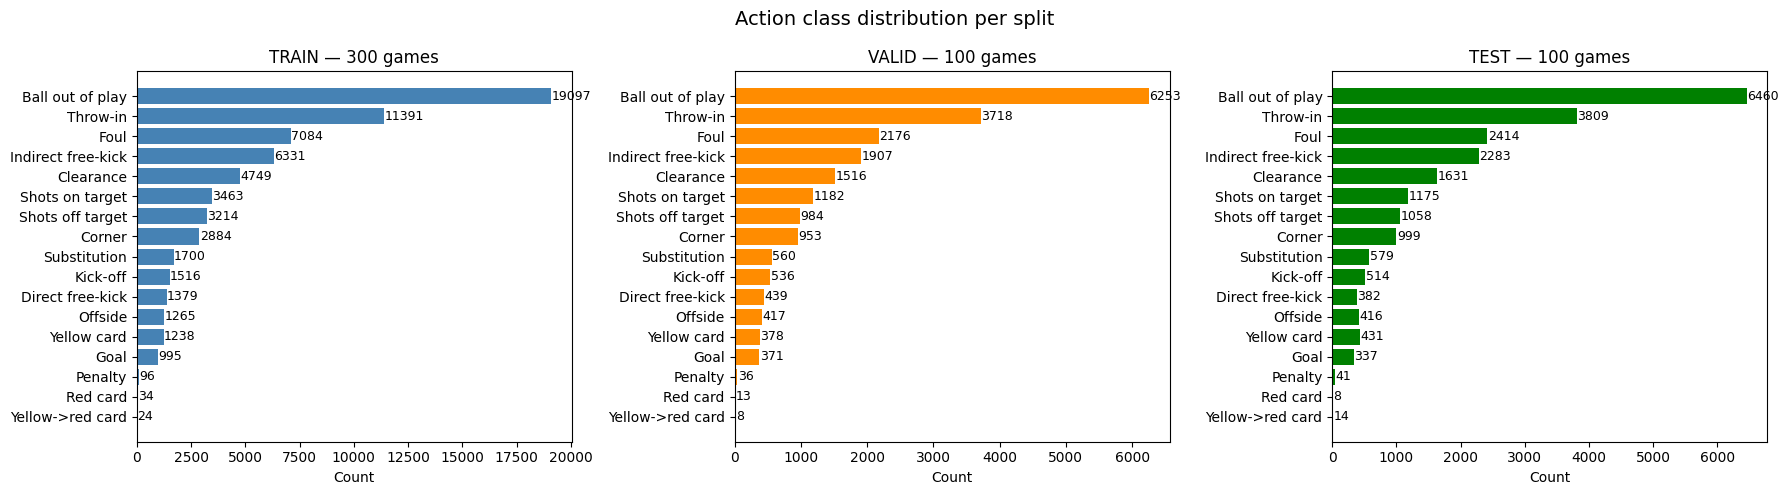

Figure saved to results/figures/


In [15]:
import sys
sys.path.append("../src")
from dataset import SELECTED_CLASSES
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = {"train": "steelblue", "valid": "darkorange", "test": "green"}

for idx, split in enumerate(["train", "valid", "test"]):
    counts = [split_stats[split][cls] for cls in SELECTED_CLASSES]
    axes[idx].barh(SELECTED_CLASSES, counts, color=colors[split])
    axes[idx].set_title(f"{split.upper()} — {split_game_counts[split]} games")
    axes[idx].set_xlabel("Count")
    axes[idx].invert_yaxis()
    for i, count in enumerate(counts):
        axes[idx].text(count + 10, i, str(count), va="center", fontsize=9)

plt.suptitle("Action class distribution per split", fontsize=14)
plt.tight_layout()
plt.savefig("../results/figures/split_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to results/figures/")

In [ ]:
import sys
sys.path.append("../src")

from dataset import SoccerNetDataset
from torch.utils.data import DataLoader

DATA_PATH = "D:/soccernet-data"

train_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="train",
    window_size=60,
    overlap=0.5
)

In [ ]:
from collections import Counter

from dataset import IDX_TO_CLASS, BACKGROUND_IDX

labels = [label for _, label in train_dataset.samples]
label_counts = Counter(labels)

print("Sample counts per class:")
for idx, cls in IDX_TO_CLASS.items():
    print(f"  {cls}: {label_counts[idx]}")
print(f"  Background: {label_counts[BACKGROUND_IDX]}")

print(f"\nTotal action samples: {sum(label_counts[i] for i in range(len(SELECTED_CLASSES)))}")
print(f"Total background samples: {label_counts[BACKGROUND_IDX]}")

window, label = train_dataset[0]
print(f"\nSample window shape: {window.shape}")
print(f"Sample label: {label.item()} ({IDX_TO_CLASS.get(label.item(), 'Background')})")

In [ ]:
valid_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="valid",
    window_size=60,
    overlap=0.5
)

test_dataset = SoccerNetDataset(
    data_path=DATA_PATH,
    split="test",
    window_size=60,
    overlap=0.5
)

print(f"\nDataset summary:")
print(f"  Train samples: {len(train_dataset)}")
print(f"  Valid samples: {len(valid_dataset)}")
print(f"  Test samples:  {len(test_dataset)}")

In [ ]:
import sys
sys.path.append("../src")

from dataset import get_dataloader, IDX_TO_CLASS, SELECTED_CLASSES
from collections import Counter
import torch

train_loader = get_dataloader(train_dataset, batch_size=32, use_weighted_sampler=True)
valid_loader = get_dataloader(valid_dataset, batch_size=32, shuffle=False)
test_loader = get_dataloader(test_dataset, batch_size=32, shuffle=False)

batch_windows, batch_labels = next(iter(train_loader))
print(f"Batch windows shape: {batch_windows.shape}")
print(f"Batch labels shape: {batch_labels.shape}")
print(f"Labels in this batch: {batch_labels.tolist()}")
print(f"\nClass distribution in this batch:")
batch_counts = Counter(batch_labels.tolist())
for idx in range(len(SELECTED_CLASSES) + 1):
    cls_name = IDX_TO_CLASS.get(idx, "Background")
    print(f"  {cls_name}: {batch_counts.get(idx, 0)}")

In [ ]:
import sys
sys.path.append("../src")

from model import SoccerNetTransformer
import torch

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

batch_windows, batch_labels = next(iter(train_loader))
output = model(batch_windows)

print(f"\nInput shape: {batch_windows.shape}")
print(f"Output shape: {output.shape}")
print(f"Output (first sample): {output[0].detach().numpy().round(4)}")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = model.to(device)
batch_windows, batch_labels = next(iter(train_loader))
batch_windows = batch_windows.to(device)
batch_labels = batch_labels.to(device)

output = model(batch_windows)
print(f"Input device: {batch_windows.device}")
print(f"Output device: {output.device}")
print(f"Output shape: {output.shape}")
print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1024**2:.1f} MB")

In [ ]:
import sys
sys.path.append("../src")

from model import SoccerNetTransformer
from dataset import SoccerNetDataset, get_dataloader
from pretrain import pretrain

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

pretrain_loader = get_dataloader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    use_weighted_sampler=False
)

model, history = pretrain(
    model=model,
    dataloader=pretrain_loader,
    num_epochs=2,
    learning_rate=1e-3,
    mask_ratio=0.15,
    checkpoint_dir="../checkpoints",
    device=device
)

In [ ]:
import os

checkpoint_dir = "../checkpoints"
files = os.listdir(checkpoint_dir)
print("Files in checkpoints folder:")
for f in files:
    size = os.path.getsize(os.path.join(checkpoint_dir, f)) / 1024 / 1024
    print(f"  {f}: {size:.1f} MB")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

history = np.load("../checkpoints/pretrain_history.npy")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(history) + 1), history, color="steelblue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Stage 1 pretraining loss curve")
plt.xticks(range(0, len(history) + 1, 5))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../results/figures/pretrain_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Starting loss: {history[0]:.4f}")
print(f"Final loss:    {history[-1]:.4f}")
print(f"Improvement:   {((history[0] - history[-1]) / history[0] * 100):.1f}%")

In [ ]:
import sys
sys.path.append("../src")

import torch
from dataset import SoccerNetDataset, get_dataloader
from model import SoccerNetTransformer
from finetune import finetune

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading datasets...")
train_dataset = SoccerNetDataset(
    data_path="D:/soccernet-data",
    split="train",
    window_size=60,
    overlap=0.5
)
valid_dataset = SoccerNetDataset(
    data_path="D:/soccernet-data",
    split="valid",
    window_size=60,
    overlap=0.5
)

model = SoccerNetTransformer(
    input_dim=512,
    d_model=256,
    num_heads=4,
    num_layers=3,
    dim_feedforward=512,
    dropout=0.1,
    num_classes=7
)

print("Loading pretrained weights...")
checkpoint = torch.load("../checkpoints/pretrain_best.pt", map_location=device, weights_only=True)
model.load_state_dict(checkpoint["model_state_dict"])
print(f"  Loaded from epoch {checkpoint['epoch']} "
      f"(pretrain loss: {checkpoint['loss']:.4f})")

model, history = finetune(
    model=model,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    num_epochs=3,
    learning_rate=1e-4,
    batch_size=32,
    checkpoint_dir="../checkpoints",
    patience=7,
    device=device,
    num_classes=7
)

Class to index mapping:
  Goal: 0
  Corner: 1
  Yellow card: 2
  Substitution: 3
  Shots on target: 4
  Shots off target: 5
  Background: 6
Loading datasets...
Loading train split — 300 games...
  Total samples: 100669
Loading valid split — 100 games...
  Total samples: 33618
Loading pretrained weights...


C:\Users\avram\AppData\Local\Temp\ipykernel_11868\3828640175.py:36: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("../checkpoints/pretrain_best.pt", 

  Loaded from epoch 50 (pretrain loss: 0.5702)
Starting Stage 2 fine-tuning on cuda
  Epochs        : 3 (patience=7)
  Learning rate : 0.0001
  Batch size    : 32
  Train samples : 100669
  Valid samples : 33618
------------------------------------------------------------


Epoch 01/3 | Train Loss: 0.3047 | Train Acc: 72.6% | Val Loss: 2.2702 | Val Acc: 29.6% | LR: 0.000075
  -> New best model saved (val_loss: 2.2702, val_acc: 29.6%)


Epoch 02/3 | Train Loss: 0.1521 | Train Acc: 81.7% | Val Loss: 2.0264 | Val Acc: 41.2% | LR: 0.000026
  -> New best model saved (val_loss: 2.0264, val_acc: 41.2%)


Epoch 03/3 | Train Loss: 0.1051 | Train Acc: 85.8% | Val Loss: 2.0256 | Val Acc: 41.6% | LR: 0.000001
  -> New best model saved (val_loss: 2.0256, val_acc: 41.6%)
------------------------------------------------------------
Fine-tuning complete.
Best validation loss: 2.0256


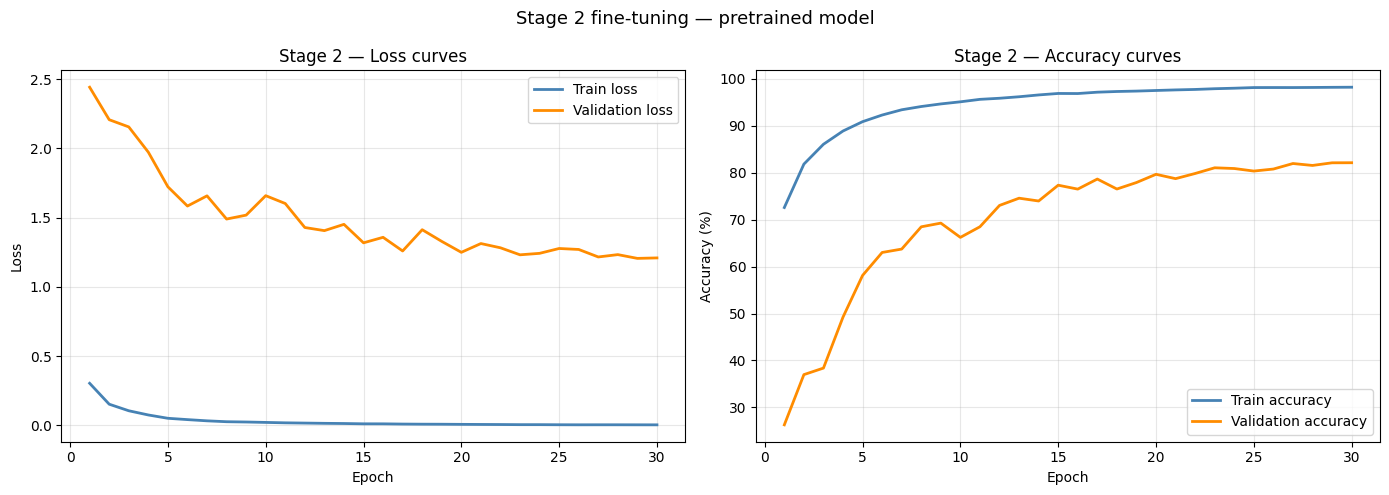

Best validation accuracy: 82.1%
Best validation loss: 1.2062


In [1]:
import numpy as np
import matplotlib.pyplot as plt

history = np.load("../checkpoints/finetune_history.npy", allow_pickle=True).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

ax1.plot(epochs, history["train_loss"], color="steelblue", 
         linewidth=2, label="Train loss")
ax1.plot(epochs, history["val_loss"], color="darkorange", 
         linewidth=2, label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Stage 2 — Loss curves")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, history["train_acc"], color="steelblue", 
         linewidth=2, label="Train accuracy")
ax2.plot(epochs, history["val_acc"], color="darkorange", 
         linewidth=2, label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Stage 2 — Accuracy curves")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Stage 2 fine-tuning — pretrained model", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/finetune_curves_pretrained.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print(f"Best validation accuracy: {max(history['val_acc']):.1f}%")
print(f"Best validation loss: {min(history['val_loss']):.4f}")

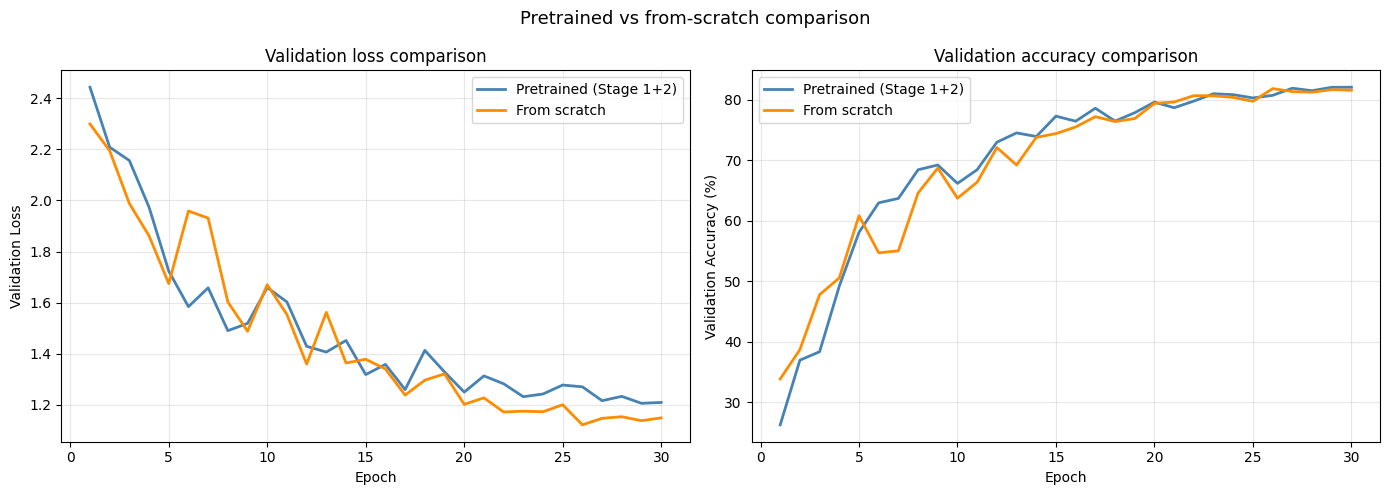

PRETRAINED MODEL:
  Best val accuracy : 82.1%
  Best val loss     : 1.2062

FROM SCRATCH MODEL:
  Best val accuracy : 81.9%
  Best val loss     : 1.1220


In [1]:
import numpy as np
import matplotlib.pyplot as plt

pretrained_history = np.load("../checkpoints/finetune_history.npy", 
                              allow_pickle=True).item()
scratch_history = np.load("../checkpoints/finetune_scratch_history.npy", 
                           allow_pickle=True).item()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_p = range(1, len(pretrained_history["val_loss"]) + 1)
epochs_s = range(1, len(scratch_history["val_loss"]) + 1)

ax1.plot(epochs_p, pretrained_history["val_loss"], 
         color="steelblue", linewidth=2, label="Pretrained (Stage 1+2)")
ax1.plot(epochs_s, scratch_history["val_loss"], 
         color="darkorange", linewidth=2, label="From scratch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Validation Loss")
ax1.set_title("Validation loss comparison")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_p, pretrained_history["val_acc"], 
         color="steelblue", linewidth=2, label="Pretrained (Stage 1+2)")
ax2.plot(epochs_s, scratch_history["val_acc"], 
         color="darkorange", linewidth=2, label="From scratch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy (%)")
ax2.set_title("Validation accuracy comparison")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Pretrained vs from-scratch comparison", fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/pretrained_vs_scratch.png", 
            dpi=150, bbox_inches="tight")
plt.show()

print("PRETRAINED MODEL:")
print(f"  Best val accuracy : {max(pretrained_history['val_acc']):.1f}%")
print(f"  Best val loss     : {min(pretrained_history['val_loss']):.4f}")
print(f"\nFROM SCRATCH MODEL:")
print(f"  Best val accuracy : {max(scratch_history['val_acc']):.1f}%")
print(f"  Best val loss     : {min(scratch_history['val_loss']):.4f}")

In [1]:
import torch
import numpy as np

checkpoint_dir = "../checkpoints"
device = torch.device("cpu")

checkpoints = {
    "100% pretrained": "finetune_best.pt",
    "100% scratch":    "finetune_scratch_best.pt",
    "50% pretrained":  "finetune_50pct_best.pt",
    "50% scratch":     "finetune_50pct_scratch_best.pt",
    "10% pretrained":  "finetune_10pct_best.pt",
    "10% scratch":     "finetune_10pct_scratch_best.pt",
}

results = {}
for name, filename in checkpoints.items():
    path = f"{checkpoint_dir}/{filename}"
    ckpt = torch.load(path, map_location=device, weights_only=False)
    val_acc = ckpt["val_acc"]
    epoch = ckpt["epoch"]
    results[name] = val_acc
    print(f"{name:25s} | epoch {epoch:3d} | val_acc: {val_acc:.2f}%")

100% pretrained           | epoch  54 | val_acc: 82.82%
100% scratch              | epoch  26 | val_acc: 81.87%
50% pretrained            | epoch  18 | val_acc: 82.99%
50% scratch               | epoch  29 | val_acc: 81.60%
10% pretrained            | epoch   7 | val_acc: 77.53%
10% scratch               | epoch  25 | val_acc: 76.30%


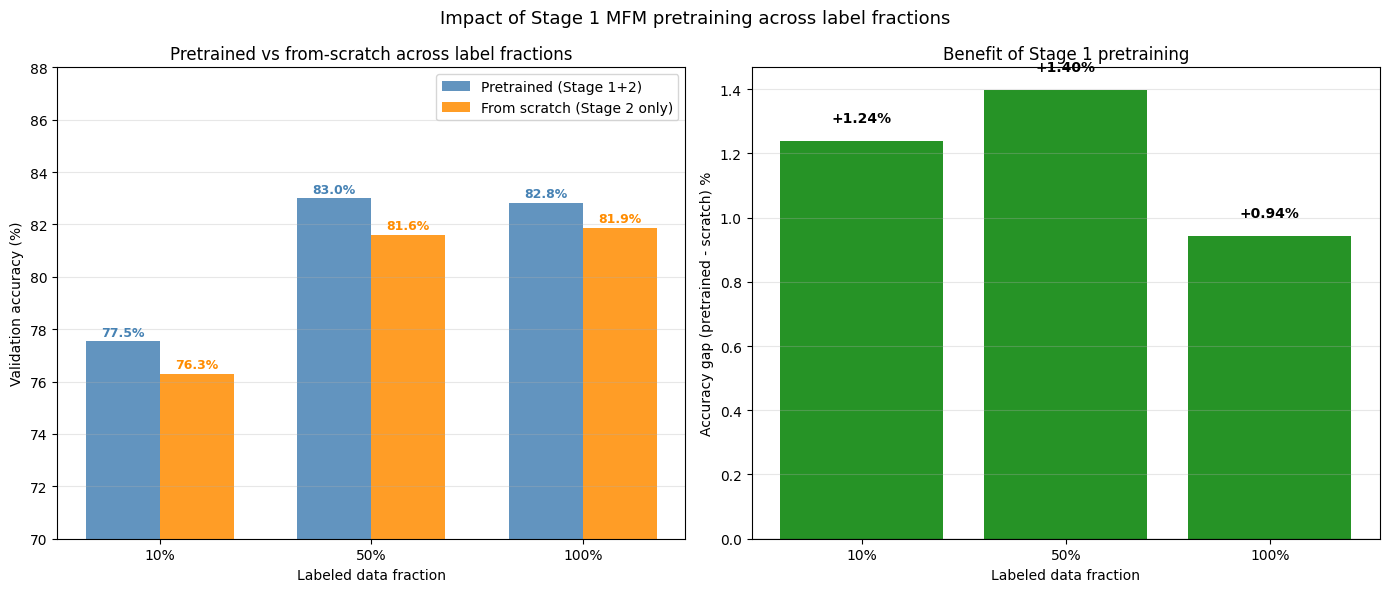


Full results summary:
Label fraction         Pretrained      Scratch        Gap
--------------------------------------------------------
10%                        77.53%       76.30%     +1.24%
50%                        82.99%       81.60%     +1.40%
100%                       82.82%       81.87%     +0.94%


In [2]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["10%", "50%", "100%"]

pretrained_accs = [
    results["10% pretrained"],
    results["50% pretrained"],
    results["100% pretrained"]
]

scratch_accs = [
    results["10% scratch"],
    results["50% scratch"],
    results["100% scratch"]
]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

bars1 = ax1.bar(x - width/2, pretrained_accs, width,
                label="Pretrained (Stage 1+2)",
                color="steelblue", alpha=0.85)
bars2 = ax1.bar(x + width/2, scratch_accs, width,
                label="From scratch (Stage 2 only)",
                color="darkorange", alpha=0.85)

ax1.set_xlabel("Labeled data fraction")
ax1.set_ylabel("Validation accuracy (%)")
ax1.set_title("Pretrained vs from-scratch across label fractions")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(70, 88)
ax1.legend()
ax1.grid(True, alpha=0.3, axis="y")

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="steelblue")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f"{bar.get_height():.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="darkorange")

gaps = [p - s for p, s in zip(pretrained_accs, scratch_accs)]
colors = ["green" if g > 0 else "red" for g in gaps]
bars3 = ax2.bar(labels, gaps, color=colors, alpha=0.85)

ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_xlabel("Labeled data fraction")
ax2.set_ylabel("Accuracy gap (pretrained - scratch) %")
ax2.set_title("Benefit of Stage 1 pretraining")
ax2.grid(True, alpha=0.3, axis="y")

for bar, gap in zip(bars3, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.05 if gap > 0 else bar.get_height() - 0.15,
             f"+{gap:.2f}%" if gap > 0 else f"{gap:.2f}%",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.suptitle("Impact of Stage 1 MFM pretraining across label fractions",
             fontsize=13)
plt.tight_layout()
plt.savefig("../results/figures/final_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nFull results summary:")
print(f"{'Label fraction':<20} {'Pretrained':>12} {'Scratch':>12} {'Gap':>10}")
print("-" * 56)
for label, p, s in zip(labels, pretrained_accs, scratch_accs):
    gap = p - s
    print(f"{label:<20} {p:>11.2f}% {s:>11.2f}% {gap:>+9.2f}%")

In [1]:
import sys
sys.path.append("../src")

from dataset import SoccerNetDataset, SELECTED_CLASSES, IDX_TO_CLASS, BACKGROUND_IDX
from collections import Counter

ds = SoccerNetDataset(
    data_path="D:/soccernet-data",
    split="train",
    window_size=60,
    overlap=0
)

labels = [l for _, l in ds.samples]
counts = Counter(labels)

print(f"Total samples: {len(ds.samples)}")
print(f"\nClass distribution:")
for idx in sorted(counts.keys()):
    name = IDX_TO_CLASS.get(idx, "Background")
    print(f"  {name:<25}: {counts[idx]}")

Class to index mapping:
  Ball out of play: 0
  Throw-in: 1
  Foul: 2
  Indirect free-kick: 3
  Clearance: 4
  Shots on target: 5
  Shots off target: 6
  Corner: 7
  Substitution: 8
  Kick-off: 9
  Direct free-kick: 10
  Offside: 11
  Yellow card: 12
  Goal: 13
  Penalty: 14
  Red card: 15
  Yellow->red card: 16
  Background: 17
Loading train split — 300 games...
  Total samples: 82453
Total samples: 82453

Class distribution:
  Ball out of play         : 19079
  Throw-in                 : 11379
  Foul                     : 7061
  Indirect free-kick       : 6320
  Clearance                : 4737
  Shots on target          : 2951
  Shots off target         : 2772
  Corner                   : 2876
  Substitution             : 1612
  Kick-off                 : 1495
  Direct free-kick         : 1191
  Offside                  : 1260
  Yellow card              : 1232
  Goal                     : 965
  Penalty                  : 39
  Red card                 : 34
  Yellow->red card         :

In [2]:
import sys
sys.path.append("../src")
from model import SoccerNetTransformer
from utils import count_parameters

model = SoccerNetTransformer(
    input_dim=512,
    d_model=384,
    num_heads=4,
    num_layers=3,
    dim_feedforward=768,
    dropout=0.1,
    num_classes=18
)
count_parameters(model)

Total parameters     : 3,755,538
Trainable parameters : 3,755,538


(3755538, 3755538)

In [1]:
import sys
sys.path.append("../src")
import torch
from model import SoccerNetTCN
from utils import count_parameters

model = SoccerNetTCN(
    input_dim=512,
    d_model=256,
    num_layers=8,
    kernel_size=3,
    dropout=0.1,
    num_classes=18
)

count_parameters(model)

x = torch.randn(1, 5400, 512)
output = model(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {output.shape}")
print(f"Output at frame 100: {output[0, 100, :].detach().numpy().round(3)}")

Total parameters     : 1,714,962
Trainable parameters : 1,714,962

Input shape:  torch.Size([1, 5400, 512])
Output shape: torch.Size([1, 5400, 18])
Output at frame 100: [-2.053  4.847 -2.265 -7.707 -8.209  1.007  2.099 -2.212 10.158 -5.355
  3.88  -3.501  2.991 -1.173 -4.195  3.993  9.911 -0.823]


In [2]:
from game_dataset import SoccerNetGameDataset, get_game_dataloader

train_game_dataset = SoccerNetGameDataset(
    data_path="D:/soccernet-data",
    split="train",
    fps=2,
    label_radius=4
)

train_game_loader = get_game_dataloader(train_game_dataset, shuffle=True)

features, labels = next(iter(train_game_loader))
print(f"Features shape: {features.shape}")
print(f"Labels shape:   {labels.shape}")
print(f"Unique labels:  {labels.unique().tolist()}")
print(f"Background frames: {(labels == 17).sum().item()}")
print(f"Action frames:     {(labels != 17).sum().item()}")

Class to index mapping:
  Ball out of play: 0
  Throw-in: 1
  Foul: 2
  Indirect free-kick: 3
  Clearance: 4
  Shots on target: 5
  Shots off target: 6
  Corner: 7
  Substitution: 8
  Kick-off: 9
  Direct free-kick: 10
  Offside: 11
  Yellow card: 12
  Goal: 13
  Penalty: 14
  Red card: 15
  Yellow->red card: 16
  Background: 17
Loading train split — 300 games...
  Total halves loaded: 600
  Total frames: 3,301,152
  Action frames: 543,525 (16.5%)
  Background frames: 2,757,627 (83.5%)
Features shape: torch.Size([1, 5880, 512])
Labels shape:   torch.Size([1, 5880])
Unique labels:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 17]
Background frames: 4972
Action frames:     908


In [1]:
import numpy as np
import os

sample_game = "D:/soccernet-data/england_epl/2014-2015/2015-02-21 - 18-00 Chelsea 1 - 1 Burnley"

baidu_half1 = np.load(os.path.join(sample_game, "1_baidu_soccer_embeddings.npy"))
baidu_half2 = np.load(os.path.join(sample_game, "2_baidu_soccer_embeddings.npy"))

print(f"Baidu half 1 shape: {baidu_half1.shape}")
print(f"Baidu half 2 shape: {baidu_half2.shape}")
print(f"Feature dimensions: {baidu_half1.shape[1]}")
print(f"Frames per half: {baidu_half1.shape[0]}")
print(f"\nFeature statistics:")
print(f"  Min: {baidu_half1.min():.4f}")
print(f"  Max: {baidu_half1.max():.4f}")
print(f"  Mean: {baidu_half1.mean():.4f}")
print(f"  Std: {baidu_half1.std():.4f}")

resnet_half1 = np.load(os.path.join(sample_game, "1_ResNET_TF2_PCA512.npy"))
print(f"\nComparison:")
print(f"  ResNet PCA512 shape: {resnet_half1.shape}")
print(f"  Baidu shape:         {baidu_half1.shape}")
print(f"  Dimension increase:  {baidu_half1.shape[1] / resnet_half1.shape[1]:.1f}x")

Baidu half 1 shape: (2700, 8576)
Baidu half 2 shape: (2700, 8576)
Feature dimensions: 8576
Frames per half: 2700

Feature statistics:
  Min: -0.0170
  Max: 1.5528
  Mean: 0.0313
  Std: 0.0641

Comparison:
  ResNet PCA512 shape: (5400, 512)
  Baidu shape:         (2700, 8576)
  Dimension increase:  16.8x


In [2]:
import sys
sys.path.append("../src")
import torch
from model import SoccerNetTCN
from utils import count_parameters

model = SoccerNetTCN(
    input_dim=8576,
    d_model=256,
    num_layers=8,
    kernel_size=3,
    dropout=0.1,
    num_classes=18
)

count_parameters(model)

x = torch.randn(1, 2700, 8576)
output = model(x)
print(f"\nInput shape:  {x.shape}")
print(f"Output shape: {output.shape}")

Total parameters     : 3,779,858
Trainable parameters : 3,779,858

Input shape:  torch.Size([1, 2700, 8576])
Output shape: torch.Size([1, 2700, 18])


In [2]:
import sys
sys.path.append("../src")

from game_dataset import SoccerNetGameDataset, get_game_dataloader

ds = SoccerNetGameDataset('D:/soccernet-data', 'train', 'baidu', 2)
loader = get_game_dataloader(ds, shuffle=False)
f, l = next(iter(loader))
print('Features:', f.shape)
print('Labels:', l.shape)
print('Action frames:', (l != 17).sum().item())
print('Background:',    (l == 17).sum().item())

Class to index mapping:
  Ball out of play: 0
  Throw-in: 1
  Foul: 2
  Indirect free-kick: 3
  Clearance: 4
  Shots on target: 5
  Shots off target: 6
  Corner: 7
  Substitution: 8
  Kick-off: 9
  Direct free-kick: 10
  Offside: 11
  Yellow card: 12
  Goal: 13
  Penalty: 14
  Red card: 15
  Yellow->red card: 16
  Background: 17
Loading train split — 300 games...
  Feature type : baidu
  FPS          : 1
  Input dim    : 8576
  Lazy loading : enabled (features loaded on demand)
  Total halves: 600
  Estimated action frames: ~332,300
  Estimated total frames:  ~1,620,000
  Estimated action ratio:  ~20.5%
Features: torch.Size([1, 2700, 8576])
Labels: torch.Size([1, 2700])
Action frames: 459
Background: 2241


In [1]:
import sys
sys.path.append("../src")

import os
import shutil
from SoccerNet.utils import getListGames

game_list = getListGames("train")

src_root = "D:/soccernet-data"
dst_root = "C:/soccernet-ssd"

print(f"Copying Baidu features for {len(game_list)} training games...")
print(f"Estimated size: ~{len(game_list) * 2 * 88 / 1024:.1f} GB")

total_copied = 0
total_skipped = 0

for i, game in enumerate(game_list):
    src_game_path = os.path.join(src_root, game)
    dst_game_path = os.path.join(dst_root, game)
    os.makedirs(dst_game_path, exist_ok=True)

    for half in ["1", "2"]:
        filename = f"{half}_baidu_soccer_embeddings.npy"
        src_file = os.path.join(src_game_path, filename)
        dst_file = os.path.join(dst_game_path, filename)

        if os.path.exists(src_file):
            if not os.path.exists(dst_file):
                shutil.copy2(src_file, dst_file)
                total_copied += 1
            else:
                total_skipped += 1

    label_src = os.path.join(src_game_path, "Labels-v2.json")
    label_dst = os.path.join(dst_game_path, "Labels-v2.json")
    if os.path.exists(label_src) and not os.path.exists(label_dst):
        shutil.copy2(label_src, label_dst)

    if (i + 1) % 50 == 0:
        print(f"  Progress: {i+1}/{len(game_list)} games done...")

print(f"\nDone.")
print(f"  Copied:  {total_copied} feature files")
print(f"  Skipped: {total_skipped} already existing files")
print(f"  Data ready at: {dst_root}")

Copying Baidu features for 300 training games...
Estimated size: ~51.6 GB
  Progress: 50/300 games done...
  Progress: 100/300 games done...
  Progress: 150/300 games done...
  Progress: 200/300 games done...
  Progress: 250/300 games done...
  Progress: 300/300 games done...

Done.
  Copied:  600 feature files
  Skipped: 0 already existing files
  Data ready at: C:/soccernet-ssd


In [2]:
import sys
sys.path.append("../src")

import os
import shutil
from SoccerNet.utils import getListGames

game_list = getListGames("valid")

src_root = "D:/soccernet-data"
dst_root = "C:/soccernet-ssd"

print(f"Copying Baidu features for {len(game_list)} validation games...")
print(f"Estimated size: ~{len(game_list) * 2 * 88 / 1024:.1f} GB")

total_copied = 0

for i, game in enumerate(game_list):
    src_game_path = os.path.join(src_root, game)
    dst_game_path = os.path.join(dst_root, game)
    os.makedirs(dst_game_path, exist_ok=True)

    for half in ["1", "2"]:
        filename = f"{half}_baidu_soccer_embeddings.npy"
        src_file = os.path.join(src_game_path, filename)
        dst_file = os.path.join(dst_game_path, filename)

        if os.path.exists(src_file) and not os.path.exists(dst_file):
            shutil.copy2(src_file, dst_file)
            total_copied += 1

    label_src = os.path.join(src_game_path, "Labels-v2.json")
    label_dst = os.path.join(dst_game_path, "Labels-v2.json")
    if os.path.exists(label_src) and not os.path.exists(label_dst):
        shutil.copy2(label_src, label_dst)

    if (i + 1) % 25 == 0:
        print(f"  Progress: {i+1}/{len(game_list)} games done...")

print(f"\nDone. Copied {total_copied} files.")

Copying Baidu features for 100 validation games...
Estimated size: ~17.2 GB
  Progress: 25/100 games done...
  Progress: 50/100 games done...
  Progress: 75/100 games done...
  Progress: 100/100 games done...

Done. Copied 200 files.


In [1]:
import os
import shutil
from SoccerNet.utils import getListGames

game_list = getListGames("test")
src_root = "D:/soccernet-data"
dst_root = "C:/soccernet-ssd"

print(f"Copying test Baidu features for {len(game_list)} games...")
total_copied = 0

for i, game in enumerate(game_list):
    src_game_path = os.path.join(src_root, game)
    dst_game_path = os.path.join(dst_root, game)
    os.makedirs(dst_game_path, exist_ok=True)

    for half in ["1", "2"]:
        filename = f"{half}_baidu_soccer_embeddings.npy"
        src_file = os.path.join(src_game_path, filename)
        dst_file = os.path.join(dst_game_path, filename)
        if os.path.exists(src_file) and not os.path.exists(dst_file):
            shutil.copy2(src_file, dst_file)
            total_copied += 1

    label_src = os.path.join(src_game_path, "Labels-v2.json")
    label_dst = os.path.join(dst_game_path, "Labels-v2.json")
    if os.path.exists(label_src) and not os.path.exists(label_dst):
        shutil.copy2(label_src, label_dst)

    if (i + 1) % 25 == 0:
        print(f"  {i+1}/{len(game_list)} done...")

print(f"Copied {total_copied} files.")

Copying test Baidu features for 100 games...
  25/100 done...
  50/100 done...
  75/100 done...
  100/100 done...
Copied 200 files.
